In [1]:
from pathlib import Path
from datetime import datetime
import quant
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
CONFIG_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "lseg-data.config.json"
VIX_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "data" / "vix.csv"
session = quant.SessionProvider(CONFIG_PATH)

In [3]:
vix = pd.read_csv(VIX_PATH, sep='\t', parse_dates=True, index_col=0).rename(columns={"Close": "VIX_Close"})

In [4]:
with session as client:
    bonds_l1 = client.bonds.list_securities("Constellation Brands Inc")
    stocks = client.equities.list_securities("Constellation Brands Inc")
    
    bonds = client.bonds.upgrade_l1_bond(bonds_l1)

In [5]:
for bond in bonds:
    print(f'{bond.name}, issued {bond.issue_date} ({bond.coupon()})')

Constellation Brands Inc, Commercial Paper, STZ 0 24-Apr-2026, issued 2026-04-15 00:00:00 (0.0)
Constellation Brands Inc, Commercial Paper, STZ 0 27-Apr-2026, issued None (0.0)
Constellation Brands Inc, Commercial Paper, STZ 0 28-Apr-2026, issued None (0.0)
Constellation Brands Inc, Commercial Paper, STZ 0 04-May-2026, issued None (0.0)
Constellation Brands Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible STZ 3.7 06-Dec-2026, issued 2016-12-06 00:00:00 (3.7)
Constellation Brands Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible STZ 4.35 09-May-2027, issued 2022-05-09 00:00:00 (4.35)
Constellation Brands Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible STZ 3.5 09-May-2027, issued 2017-05-09 00:00:00 (3.5)
Constellation Brands Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible STZ 3.6 15-Feb-2028, issued 2018-02-07 00:00:00 (3.6)
Constellation Brands Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible STZ 4.65 15-Nov-2028, issued 2018-10-29 00:00:00 (4.65)
Constellation Bra

In [6]:
common_stock = next(filter(lambda stock: stock.ric == "STZ", stocks))
print(common_stock.name)

Constellation Brands Inc, Ordinary Share, Class A, NYSE Consolidated


In [7]:
bonds_d = [bond for bond in bonds if bond.coupon() != 0.0]

In [8]:
first_issuance = min(bonds_d, key=lambda bond: bond.issue_date)
print(f"Earliest issuance is {first_issuance.issue_date}, {first_issuance.name}")

Earliest issuance is 2016-12-06 00:00:00, Constellation Brands Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible STZ 3.7 06-Dec-2026


In [9]:
START = first_issuance.issue_date
END = datetime.today()

In [10]:
study = quant.study.fi_ltm.FILtmStudy(START, END, quant.Interval.DAILY, vix)

In [11]:
ready_to_run = study.prepare_args(common_stock, bonds, 0.045)

In [12]:
df_results = ready_to_run.run(session)

Pull IV history
Pull stock history


Pull bond history: 7it [00:13,  1.92s/it]
Build engineered features: 100%|██████████| 16/16 [00:11<00:00,  1.38it/s]


In [15]:
for col in df_results:
    rows = df_results[col]
    print(rows)

Fold 1    0.548387
Fold 2    0.458781
Fold 3    0.594982
Fold 4    0.351254
Fold 5    0.577061
Name: 2026-12-06 00:00:00 - 3.7, dtype: float64
Fold 1    0.443182
Fold 2    0.795455
Fold 3    0.534091
Fold 4    0.772727
Fold 5    0.579545
Name: 2027-05-09 00:00:00 - 4.35, dtype: float64
Fold 1    0.722022
Fold 2    0.628159
Fold 3    0.638989
Fold 4    0.361011
Fold 5    0.566787
Name: 2027-05-09 00:00:00 - 3.5, dtype: float64
Fold 1    0.521912
Fold 2    0.673307
Fold 3    0.533865
Fold 4    0.653386
Fold 5    0.565737
Name: 2028-02-15 00:00:00 - 3.6, dtype: float64
Fold 1    0.540909
Fold 2    0.677273
Fold 3    0.463636
Fold 4    0.450000
Fold 5    0.609091
Name: 2028-11-15 00:00:00 - 4.65, dtype: float64
Fold 1    0.756098
Fold 2    0.341463
Fold 3    0.365854
Fold 4    0.975610
Fold 5    0.439024
Name: 2029-01-15 00:00:00 - 4.8, dtype: float64
Fold 1    0.547872
Fold 2    0.526596
Fold 3    0.414894
Fold 4    0.590426
Fold 5    0.670213
Name: 2029-08-01 00:00:00 - 3.15, dtype: floa

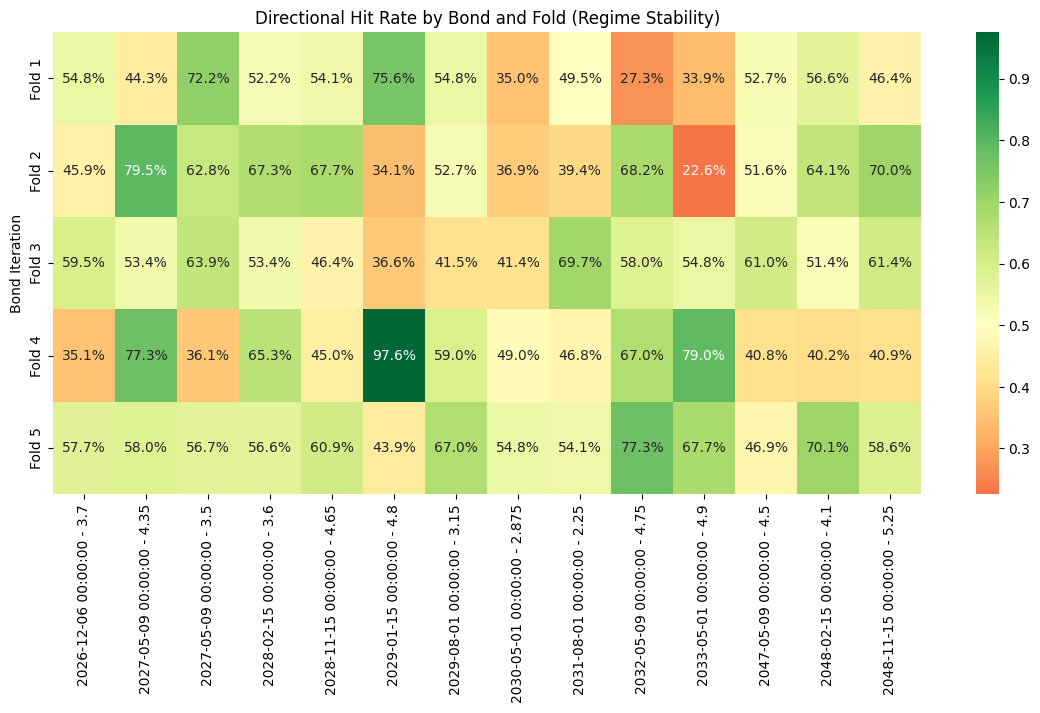

In [13]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(df_results, annot=True, fmt=".1%", cmap="RdYlGn", center=0.5)
plt.title("Directional Hit Rate by Bond and Fold (Regime Stability)")
plt.ylabel("Bond Iteration")
plt.show()